In [1]:
!pip install -qq git+https://github.com/csebuetnlp/normalizer
!pip install -Uq bitsandbytes
!pip install -Uq transformers peft
!pip install -qq pycocoevalcap  # CIDEr (official MS-COCO eval toolkit)


  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 7.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 23.1 MB/s eta 0:00:00


In [2]:
import warnings
import os
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings('ignore', message='.*unexpected keys.*')
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
import warnings
import os
import re
import torch
import torch.nn as nn
from collections import OrderedDict
from typing import Optional, Union, Tuple
from PIL import Image
from torch.utils.data import Dataset
from transformers import (
    Blip2Processor, 
    Blip2PreTrainedModel,
    Blip2Config,
    Blip2VisionModel,
    Blip2QFormerModel,
    AutoTokenizer, 
    AutoModelForSeq2SeqLM,
    AutoConfig,
    TrainingArguments, 
    Trainer,
    BitsAndBytesConfig
)
from transformers.models.blip_2.modeling_blip_2 import Blip2ForConditionalGenerationModelOutput
from torch.nn import CrossEntropyLoss
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from torch.optim import AdamW
import random
from normalizer import normalize
import unicodedata
import transformers
import tokenizers
import sentencepiece

print(f"    transformers:  {transformers.__version__}")
print(f"    tokenizers:    {tokenizers.__version__}")
print(f"    sentencepiece: {sentencepiece.__version__}")


os.environ["CUDA_VISIBLE_DEVICES"] = "0"

def bangla_postprocess(text):
    if not text or not isinstance(text, str):
        return text
    text = unicodedata.normalize('NFC', text)
    text = text.replace('\u200b', '')   
    text = text.replace('\u200c', '')  
    text = text.replace('\u200d', '')  
    text = text.replace('\ufeff', '')   
    text = re.sub(r'(?<![অ-হড়ঢ়য়ৎংঃঁ])[\u09BE-\u09CD\u09D7\u09BC]', '', text)
    text = normalize(text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    deduped = [words[0]] if words else []
    for w in words[1:]:
        if w != deduped[-1]:
            deduped.append(w)
    text = ' '.join(deduped)

    if text.endswith('.'):
        text = text[:-1] + '।'

    return text

    transformers:  5.3.0
    tokenizers:    0.22.2
    sentencepiece: 0.2.1


In [4]:
class Config:
    images_dir    = "/kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/Pictures"
    captions_file = "/kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/caption/caption.txt"
    train_split   = "/kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/caption/train.txt"
    val_split     = "/kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/caption/validation.txt"
    test_split    = "/kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/caption/test.txt"
    output_dir    = "/kaggle/working/blip2_bangla_output"

    blip_checkpoint = "Salesforce/blip2-flan-t5-xl"
    bangla_model_id = "csebuetnlp/banglat5"

    max_len    = 128
    image_size = 224

    batch_size_s1            = 96
    gradient_accumulation_s1 = 1
    lr_stage1                = 2e-4
    epochs_stage1            = 5

    num_workers = 16

    batch_size_s2            = 64
    gradient_accumulation_s2 = 2
    lr_qformer               = 1e-5
    lr_lora                  = 2e-5
    weight_decay             = 0.05
    epochs_stage2            = 30
    warmup_steps_s2          = 300

    lora_r       = 128
    lora_alpha   = 256
    lora_dropout = 0.05

    max_gen_length = 64
    num_beams      = 5
    length_penalty = 1.7

    device   = "cuda" if torch.cuda.is_available() else "cpu"
    use_8bit = True


config = Config()

import os
print("images_dir    :", os.path.exists(config.images_dir))
print("captions_file :", os.path.exists(config.captions_file))

images_dir    : True
captions_file : True


In [5]:
class BanglaBLIP(Blip2PreTrainedModel):
    def __init__(self,
                 blip_pretrained="Salesforce/blip2-flan-t5-xl",
                 bangla_lm_pretrained="csebuetnlp/banglat5",
                 load_8bit=True,
                 freeze_vit=True,
                 freeze_qformer=True,
                 freeze_lm=True,
                 freeze_projection=False,
                 use_lora=False,
                 lora_alpha=16,
                 lora_r=8,
                 lora_dropout=0.05,
                 lora_bias="none",
                 lora_checkpoint=None):

        from transformers import Blip2ForConditionalGeneration

        blip2_model = Blip2ForConditionalGeneration.from_pretrained(
            blip_pretrained,
            torch_dtype=torch.float16,
        )

        config = blip2_model.config
        bangla_config = AutoConfig.from_pretrained(bangla_lm_pretrained)
        config.text_config = bangla_config

        super().__init__(config)

        self.vision_model = blip2_model.vision_model
        print("Vision Encoder (pretrained)")

        self.qformer = blip2_model.qformer
        print("Q-Former (pretrained)")

        self.query_tokens = blip2_model.query_tokens
        print("Query Tokens (pretrained)")

        print("\nReinitializing projection layer for Bangla LLM :")
        print(f"  Old dimension: {blip2_model.language_projection.out_features}")
        print(f"  New dimension: {bangla_config.d_model}")

        self.language_projection = nn.Sequential(
            nn.Linear(self.qformer.config.hidden_size, bangla_config.d_model),
            nn.GELU(),
            nn.Linear(bangla_config.d_model, bangla_config.d_model)
        )

        for layer in self.language_projection:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, std=0.02)
                nn.init.zeros_(layer.bias)

        self.language_projection_ln = nn.LayerNorm(bangla_config.d_model)
        self.language_projection_ln.requires_grad_(True)

        print("Discarding BLIP-2's English LLM \n")
        del blip2_model.language_model
        del blip2_model
        torch.cuda.empty_cache()
        print("English LLM removed")

        print(f"Loading Bangla LLM: {bangla_lm_pretrained}\n")
        rank = int(os.environ.get("LOCAL_RANK", 0))
        self.llm_cast_dtype = torch.bfloat16

        if isinstance(load_8bit, str) and load_8bit == "4bit":
            print("Mode: 4-bit quantization")
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=self.llm_cast_dtype,
            )
            self.language_model = AutoModelForSeq2SeqLM.from_pretrained(
                bangla_lm_pretrained,
                dtype="auto",          
                quantization_config=bnb_config,
                device_map={"": rank},
            )
        elif load_8bit:
            print("Mode: 8-bit quantization")
            bnb_config = BitsAndBytesConfig(load_in_8bit=True)
            self.language_model = AutoModelForSeq2SeqLM.from_pretrained(
                bangla_lm_pretrained,
                dtype="auto",         
                quantization_config=bnb_config,
                device_map={"": rank},
            )
        else:
            print("Full precision")
            self.language_model = AutoModelForSeq2SeqLM.from_pretrained(
                bangla_lm_pretrained,
                dtype="auto",         
                device_map={"": rank},
            )

        if freeze_vit:
            for param in self.vision_model.parameters():
                param.requires_grad = False

        if freeze_qformer:
            self.query_tokens.requires_grad = False
            for param in self.qformer.parameters():
                param.requires_grad = False

        if freeze_lm:
            for param in self.language_model.parameters():
                param.requires_grad = False

        if freeze_projection:
            for param in self.language_projection.parameters():
                param.requires_grad = False
        else:
            print("Projection layer trainable")

        if use_lora:
            self.language_model = prepare_model_for_kbit_training(
                self.language_model,
                use_gradient_checkpointing=True
            )

            if lora_checkpoint and os.path.exists(lora_checkpoint):
                print(f"  Loading LoRA adapter from {lora_checkpoint}...")
                self.language_model = PeftModel.from_pretrained(
                    self.language_model,
                    lora_checkpoint
                )
            else:
                if isinstance(use_lora, bool) or use_lora == "lora":
                    target_modules = ["q", "v"]
                elif use_lora == "lora_all":
                    target_modules = ["q", "k", "v", "o", "wi_0", "wi_1", "wo"]
                    print("LoRA on ALL matrices")

                lora_config = LoraConfig(
                    r=lora_r,
                    lora_alpha=lora_alpha,
                    target_modules=target_modules,
                    lora_dropout=lora_dropout,
                    bias=lora_bias,
                    task_type="SEQ_2_SEQ_LM"
                )

                self.language_model = get_peft_model(self.language_model, lora_config)
                self.language_model.print_trainable_parameters()

    
        self._use_lora = bool(use_lora)

    def state_dict(self, *args, destination=None, prefix='', keep_vars=False):
        if destination is None:
            destination = OrderedDict()
            destination._metadata = OrderedDict()

        local_metadata = dict(version=self._version)
        if hasattr(destination, "_metadata"):
            destination._metadata[prefix[:-1]] = local_metadata

        self._save_to_state_dict(destination, prefix, keep_vars)

        for name, module in self._modules.items():
            if module is None:
                continue

        
            if name == "vision_model":
                continue

            if name == "language_model":
                if self._use_lora:
                    lora_sd = module.state_dict(destination=None, prefix='', keep_vars=keep_vars)
                    for k, v in lora_sd.items():
                        if "lora_" in k:      
                            destination[prefix + name + "." + k] = v
                continue

            module.state_dict(
                destination=destination,
                prefix=prefix + name + ".",
                keep_vars=keep_vars
            )

        for hook in self._state_dict_hooks.values():
            hook_result = hook(self, destination, prefix, local_metadata)
            if hook_result is not None:
                destination = hook_result

        return destination

    def save_lora_adapter(self, save_directory: str):
        if not self._use_lora:
            raise RuntimeError("LoRA is not active on this model.")
        os.makedirs(save_directory, exist_ok=True)
        self.language_model.save_pretrained(save_directory)
        print(f"LoRA adapter saved to {save_directory}")

    def get_input_embeddings(self):
        return self.language_model.get_input_embeddings()

    def set_input_embeddings(self, value):
        self.language_model.set_input_embeddings(value)

    def forward(
        self,
        pixel_values: torch.FloatTensor,
        input_ids: torch.LongTensor,
        attention_mask: Optional[torch.LongTensor] = None,
        decoder_input_ids: Optional[torch.LongTensor] = None,
        decoder_attention_mask: Optional[torch.LongTensor] = None,
        output_attentions: Optional[bool] = None,
        output_hidden_states: Optional[bool] = None,
        labels: Optional[torch.LongTensor] = None,
        return_dict: Optional[bool] = None,
        **kwargs
    ) -> Union[Tuple, Blip2ForConditionalGenerationModelOutput]:

        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        num_images = 1
        if len(pixel_values.shape) == 5:
            num_images = pixel_values.shape[1]
            pixel_values = pixel_values.view(
                pixel_values.shape[0] * pixel_values.shape[1],
                *pixel_values.shape[2:]
            )

        vision_outputs = self.vision_model(
            pixel_values=pixel_values,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        image_embeds = vision_outputs[0]

        image_attention_mask = torch.ones(
            image_embeds.size()[:-1],
            dtype=torch.long,
            device=image_embeds.device
        )

        query_tokens = self.query_tokens.expand(image_embeds.shape[0], -1, -1)
        query_outputs = self.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )
        query_output = query_outputs[0]

        if num_images > 1:
            query_output = query_output.view(input_ids.shape[0], -1, query_output.shape[2])

        language_model_inputs = self.language_projection(query_output)
        language_model_inputs = self.language_projection_ln(language_model_inputs) 

        language_model_attention_mask = torch.ones(
            language_model_inputs.size()[:-1],
            dtype=torch.long,
            device=language_model_inputs.device
        )

        \
        with torch.amp.autocast("cuda", dtype=self.llm_cast_dtype):
            lm_embedding = self.language_model.get_input_embeddings()
            inputs_embeds = lm_embedding(input_ids)
            inputs_embeds = torch.cat(
                [language_model_inputs, inputs_embeds.to(language_model_inputs.device)],
                dim=1
            )

            if attention_mask is None:
                attention_mask = torch.ones_like(input_ids)

            attention_mask = torch.cat(
                [language_model_attention_mask, attention_mask.to(language_model_attention_mask.device)],
                dim=1
            )

            outputs = self.language_model(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                decoder_attention_mask=decoder_attention_mask,
                output_attentions=output_attentions,
                output_hidden_states=output_hidden_states,
                return_dict=return_dict,
                labels=labels,
            )

            loss = outputs.loss if return_dict else outputs[0]
            logits = outputs.logits if return_dict else outputs[1]

        if not return_dict:
            output = (logits, vision_outputs, query_outputs, outputs)
            return ((loss,) + output) if loss is not None else output

        return Blip2ForConditionalGenerationModelOutput(
            loss=loss,
            logits=logits,
            vision_outputs=vision_outputs,
            qformer_outputs=query_outputs,
            language_model_outputs=outputs,
        )

    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.FloatTensor,
        input_ids: Optional[torch.LongTensor] = None,
        attention_mask: Optional[torch.LongTensor] = None,
        **generate_kwargs,
    ) -> torch.LongTensor:

        num_images = 1
        orig_batch_size = pixel_values.shape[0]

        if len(pixel_values.shape) == 5:
            orig_batch_size = pixel_values.shape[0]
            num_images = pixel_values.shape[1]
            pixel_values = pixel_values.view(
                pixel_values.shape[0] * pixel_values.shape[1],
                *pixel_values.shape[2:]
            )

        image_embeds = self.vision_model(pixel_values, return_dict=True).last_hidden_state
        image_attention_mask = torch.ones(
            image_embeds.size()[:-1],
            dtype=torch.long,
            device=image_embeds.device
        )

        query_tokens = self.query_tokens.expand(image_embeds.shape[0], -1, -1)
        query_outputs = self.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_attention_mask,
            return_dict=True,
        )
        query_output = query_outputs.last_hidden_state

        if num_images > 1:
            query_output = query_output.view(orig_batch_size, -1, query_output.shape[2])

        language_model_inputs = self.language_projection(query_output)
        language_model_inputs = self.language_projection_ln(language_model_inputs)  

        language_attention_mask = torch.ones(
            language_model_inputs.size()[:-1],
            dtype=torch.long,
            device=language_model_inputs.device
        )

        if input_ids is None:
            input_ids = (
                torch.LongTensor([[self.config.text_config.bos_token_id]])
                .repeat(orig_batch_size, 1)
                .to(image_embeds.device)
            )
        if attention_mask is None:
            attention_mask = torch.ones_like(input_ids)

        attention_mask = torch.cat([language_attention_mask, attention_mask], dim=1)

        
        with torch.amp.autocast("cuda", dtype=self.llm_cast_dtype):
            lm_embedding = self.language_model.get_input_embeddings()
            inputs_embeds = lm_embedding(input_ids)
            inputs_embeds = torch.cat(
                [language_model_inputs, inputs_embeds.to(language_model_inputs.device)],
                dim=1
            )

            outputs = self.language_model.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                **generate_kwargs,
            )

        return outputs


def load_caption_map(captions_file):
    captions_dict = {}
    print(f"Loading captions from {captions_file}...")

    with open(captions_file, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split('\t', 1) if '\t' in line else line.split(None, 1)
            if parts is None or len(parts) != 2:
                continue

            filename, caption = parts
            filename = filename.replace(' ', '')
            if not filename.endswith('.jpg'):
                filename = filename + '.jpg'

            if filename not in captions_dict:
                captions_dict[filename] = []
            captions_dict[filename].append(normalize(caption) or "")

    return captions_dict


def process_split_for_training(split_file, captions_dict):
    with open(split_file, 'r', encoding='utf-8') as f:
        raw_filenames = [line.strip() for line in f if line.strip()]

    clean_filenames = []
    for fname in raw_filenames:
        fname = fname.replace(' ', '')
        if not fname.endswith('.jpg'):
            fname = fname + '.jpg'
        clean_filenames.append(fname)

    matched_data = []
    for fname in clean_filenames:
        if fname in captions_dict:
            for caption in captions_dict[fname]:
                matched_data.append((fname, caption))

    print(f"Training: {len(matched_data)} samples from {len(clean_filenames)} images")
    return matched_data


def process_split_for_evaluation(split_file, captions_dict):
    with open(split_file, 'r', encoding='utf-8') as f:
        raw_filenames = [line.strip() for line in f if line.strip()]

    clean_filenames = []
    for fname in raw_filenames:
        fname = fname.replace(' ', '')
        if not fname.endswith('.jpg'):
            fname = fname + '.jpg'
        clean_filenames.append(fname)

    matched_data = []
    for fname in clean_filenames:
        if fname in captions_dict:
            matched_data.append((fname, captions_dict[fname]))

    print(f"Evaluation: {len(matched_data)} images with multiple references")
    return matched_data


class BanglaTrainDataset(Dataset):
    def __init__(self, data_list, images_dir, processor, tokenizer):
        self.data = data_list
        self.images_dir = images_dir
        self.processor = processor
        self.tokenizer = tokenizer

        self.templates = [
            "বাংলায় ক্যাপশন:",
            "ছবির বর্ণনা:",
            "সংক্ষিপ্ত বর্ণনা:",
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filename, caption = self.data[idx]
        img_path = os.path.join(self.images_dir, filename)

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (config.image_size, config.image_size))

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        instruction = random.choice(self.templates)

        text_encoding = self.tokenizer(
            instruction,
            padding="max_length",
            max_length=config.max_len,
            truncation=True,
            return_tensors="pt"
        )

        caption_encoding = self.tokenizer(
            caption,
            padding="max_length",
            max_length=config.max_len,
            truncation=True,
            return_tensors="pt"
        )

        return {
            'pixel_values': pixel_values,
            'input_ids': text_encoding['input_ids'].squeeze(0),
            'attention_mask': text_encoding['attention_mask'].squeeze(0),
            'labels': caption_encoding['input_ids'].squeeze(0),
        }


class BanglaEvalDataset(Dataset):
    def __init__(self, data_list, images_dir, processor, tokenizer):
        self.data = data_list
        self.images_dir = images_dir
        self.processor = processor
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filename, captions = self.data[idx]
        img_path = os.path.join(self.images_dir, filename)

        try:
            image = Image.open(img_path).convert('RGB')
        except:
            image = Image.new('RGB', (config.image_size, config.image_size))

        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        instruction = "বাংলায় ক্যাপশন:"
        text_encoding = self.tokenizer(
            instruction,
            padding="max_length",
            max_length=config.max_len,
            truncation=True,
            return_tensors="pt"
        )

        primary_caption = captions[0]
        label_encoding = self.tokenizer(
            primary_caption,
            padding="max_length",
            max_length=config.max_len,
            truncation=True,
            return_tensors="pt"
        )

        return {
            'pixel_values': pixel_values,
            'input_ids': text_encoding['input_ids'].squeeze(0),
            'attention_mask': text_encoding['attention_mask'].squeeze(0),
            'labels': label_encoding['input_ids'].squeeze(0),
            'reference_captions': captions,
            'filename': filename
        }


class MultimodalCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, batch):
        pixel_values = torch.stack([item['pixel_values'] for item in batch])
        input_ids = torch.stack([item['input_ids'] for item in batch])
        attention_mask = torch.stack([item['attention_mask'] for item in batch])
        labels = torch.stack([item['labels'] for item in batch])

        labels[labels == self.tokenizer.pad_token_id] = -100

        batch_output = {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

        if 'reference_captions' in batch[0]:
            batch_output['reference_captions'] = [item['reference_captions'] for item in batch]
        if 'filename' in batch[0]:
            batch_output['filename'] = [item['filename'] for item in batch]

        return batch_output

In [6]:
import torch
import csv
import json
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction, sentence_bleu
from nltk.translate.meteor_score import meteor_score as nltk_meteor

# Download required NLTK data for METEOR (WordNet synonym matching)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# CIDEr via the official MS-COCO evaluation toolkit (pycocoevalcap)
from pycocoevalcap.cider.cider import Cider as CiderScorer


def compute_cider(predictions, references):
    """
    Compute corpus-level CIDEr using the official pycocoevalcap implementation.

    predictions : list of str   – one generated caption per image
    references  : list of list[str] – one or more reference captions per image

    Returns the mean CIDEr score (float, typically 0-10 scale).
    """
    # pycocoevalcap expects dicts keyed by image id
    gts  = {i: refs          for i, refs in enumerate(references)}
    res  = {i: [predictions[i]] for i in range(len(predictions))}

    scorer = CiderScorer()
    score, _ = scorer.compute_score(gts, res)
    return score  # mean corpus CIDEr


def evaluate_captions(model, eval_dataset, tokenizer,
                       num_samples=None,
                       csv_path="caption_eval_results.csv"):
    """
    Evaluate the model on eval_dataset and report:
      • BLEU-1 / 2 / 3 / 4  (nltk corpus_bleu)
      • METEOR               (nltk meteor_score, averaged over corpus)
      • CIDEr                (pycocoevalcap official implementation)

    Per-sample sentence-level BLEU and METEOR are written to csv_path.
    """
    model.eval()
    device = config.device

    predictions_str  = []   # raw decoded strings (for METEOR / CIDEr)
    predictions_tok  = []   # tokenised lists       (for BLEU)
    references_str   = []   # list[list[str]]       (for METEOR / CIDEr)
    references_tok   = []   # list[list[list[str]]] (for BLEU)
    rows             = []

    indices = (range(len(eval_dataset))
               if num_samples is None
               else range(min(num_samples, len(eval_dataset))))

    print(f"\nGenerating captions for {len(list(indices))} images")
    smoothie = SmoothingFunction().method1

    for idx in indices:
        sample       = eval_dataset[idx]
        pixel_values = sample['pixel_values'].unsqueeze(0).to(device)
        input_ids    = sample['input_ids'].unsqueeze(0).to(device)
        attention_mask = sample['attention_mask'].unsqueeze(0).to(device)

        with torch.no_grad():
            output_ids = model.generate(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=config.max_gen_length,
                num_beams=config.num_beams,
                length_penalty=config.length_penalty,
            )

        generated     = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        generated     = bangla_postprocess(generated)
        gen_tokens    = generated.split()

        ref_captions  = sample['reference_captions']
        ref_tokens    = [ref.split() for ref in ref_captions]

        # accumulate for corpus metrics
        predictions_str.append(generated)
        predictions_tok.append(gen_tokens)
        references_str.append(ref_captions)
        references_tok.append(ref_tokens)

        # ── sentence-level BLEU ────────────────────────────────────────────
        s_bleu1 = sentence_bleu(ref_tokens, gen_tokens, weights=(1,0,0,0),      smoothing_function=smoothie)
        s_bleu2 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.5,0.5,0,0),  smoothing_function=smoothie)
        s_bleu3 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.33,0.33,0.33,0), smoothing_function=smoothie)
        s_bleu4 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

        # ── sentence-level METEOR ─────────────────────────────────────────
        # nltk meteor_score takes list-of-reference-strings and hypothesis string
        # s_meteor = nltk_meteor(ref_captions, generated)
        s_meteor = nltk_meteor([ref.split() for ref in ref_captions], generated.split())
        rows.append({
            "filename":          sample.get("filename", f"image_{idx}"),
            "generated_caption": generated,
            "reference_captions": " ||| ".join(ref_captions),
            "sentence_bleu1":    s_bleu1,
            "sentence_bleu2":    s_bleu2,
            "sentence_bleu3":    s_bleu3,
            "sentence_bleu4":    s_bleu4,
            "sentence_meteor":   s_meteor,
        })

        if idx < 5:
            print(f"\n[Example {idx+1}]")
            print(f"Generated : {generated}")
            print("References:")
            for i, ref in enumerate(ref_captions, 1):
                print(f"  {i}. {ref}")

    # ── Corpus-level BLEU ─────────────────────────────────────────────────────
    bleu1 = corpus_bleu(references_tok, predictions_tok, weights=(1,0,0,0),        smoothing_function=smoothie)
    bleu2 = corpus_bleu(references_tok, predictions_tok, weights=(0.5,0.5,0,0),    smoothing_function=smoothie)
    bleu3 = corpus_bleu(references_tok, predictions_tok, weights=(0.33,0.33,0.33,0), smoothing_function=smoothie)
    bleu4 = corpus_bleu(references_tok, predictions_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)

    # ── Corpus-level METEOR ───────────────────────────────────────────────────
    # Average sentence-level METEOR scores over the corpus
    # (standard practice for METEOR in image captioning, same as SPICE papers)
    meteor = sum(r["sentence_meteor"] for r in rows) / len(rows) if rows else 0.0

    # ── Corpus-level CIDEr ────────────────────────────────────────────────────
    # Uses official pycocoevalcap CIDEr (TF-IDF weighted n-gram cosine similarity)
    cider = compute_cider(predictions_str, references_str)

    # ── Print results ─────────────────────────────────────────────────────────
    sep = "=" * 60
    print(f"\n{sep}")
    print("EVALUATION SCORES")
    print(sep)
    print(f"BLEU-1 : {bleu1:.4f}")
    print(f"BLEU-2 : {bleu2:.4f}")
    print(f"BLEU-3 : {bleu3:.4f}")
    print(f"BLEU-4 : {bleu4:.4f}")
    print(f"METEOR : {meteor:.4f}")
    print(f"CIDEr  : {cider:.4f}")
    print(sep)

    # ── Save CSV ──────────────────────────────────────────────────────────────
    fieldnames = [
        "filename", "generated_caption", "reference_captions",
        "sentence_bleu1", "sentence_bleu2", "sentence_bleu3", "sentence_bleu4",
        "sentence_meteor",
    ]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    print(f"Saved per-sample results to: {csv_path}")

    model.train()
    return bleu1, bleu2, bleu3, bleu4, meteor, cider


In [7]:
def get_model_and_processor():
   
    processor = Blip2Processor.from_pretrained(config.blip_checkpoint)
    print(" Processor loaded")
    

    tokenizer = AutoTokenizer.from_pretrained(config.bangla_model_id,  use_fast=False)
    print(" Tokenizer loaded")
    
    model = BanglaBLIP(
        blip_pretrained=config.blip_checkpoint,
        bangla_lm_pretrained=config.bangla_model_id,
        load_8bit=config.use_8bit,
        freeze_vit=True,           # Always frozen
        freeze_qformer=True,       # Frozen in Stage 1
        freeze_lm=True,            
        freeze_projection=False,   # Trainable in both stages
        use_lora=False,            # add LoRA in Stage 2
    )
    
    return model, processor, tokenizer

In [8]:
def run_stage1_warmup(model, dataset, val_dataset, collator):
  
    
    for param in model.parameters():
        param.requires_grad = False
    for param in model.language_projection.parameters():
        param.requires_grad = True
    
    training_args = TrainingArguments(
        output_dir=f"{config.output_dir}/stage1_warmup",
        num_train_epochs=config.epochs_stage1,
        per_device_train_batch_size=config.batch_size_s1,
        gradient_accumulation_steps=config.gradient_accumulation_s1,
        learning_rate=config.lr_stage1,
        warmup_steps=10,
        logging_strategy="steps",
        logging_steps=300,
        save_steps=1000,
        save_total_limit=1,
        fp16=True,
        # save_safetensors=False,
        remove_unused_columns=False,
        dataloader_num_workers=config.num_workers,
        eval_strategy="steps" if val_dataset else "no",
        eval_steps=300 if val_dataset else None,
        report_to="none",
        max_grad_norm=1.0
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        eval_dataset=val_dataset,
        data_collator=collator,
    )
    
    trainer.train()
    model.save_pretrained(f"{config.output_dir}/stage1_checkpoint")
    print("Stage 1 completed")
    
    return model


def run_stage2_realignment(model, dataset, val_dataset, collator, tokenizer):
    print("STAGE 2 RE-ALIGNMENT:")
 
    

    for param in model.qformer.parameters():
        param.requires_grad = True
    model.query_tokens.requires_grad = True
    
    model.language_model = prepare_model_for_kbit_training(model.language_model)
    
    lora_config = LoraConfig(
        r=config.lora_r,
        lora_alpha=config.lora_alpha,
        target_modules=["q", "k", "v", "o", "wi_0", "wi_1", "wo"],
        lora_dropout=config.lora_dropout,
        bias="none",
        task_type="SEQ_2_SEQ_LM",
    )
    
    model.language_model = get_peft_model(model.language_model, lora_config)
    model._use_lora = True 
    model.language_model.print_trainable_parameters()
    

    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() 
                      if "qformer" in n or "query_tokens" in n or "language_projection" in n],
            "lr": config.lr_qformer,
        },
        {
            "params": [p for n, p in model.named_parameters() if "lora" in n.lower()],
            "lr": config.lr_lora,
        },
    ]
    
    training_args = TrainingArguments(
        output_dir=f"{config.output_dir}/stage2_realignment",
        num_train_epochs=config.epochs_stage2,
        per_device_train_batch_size=config.batch_size_s2,
        gradient_accumulation_steps=config.gradient_accumulation_s2,
        learning_rate=config.lr_lora,
        weight_decay=config.weight_decay,
        warmup_steps=config.warmup_steps_s2,
        logging_strategy="steps",
        logging_steps=300,
        save_steps=1500,
        save_total_limit=1,
        # save_safetensors=False,
        fp16=False,
        remove_unused_columns=False,
        dataloader_num_workers=config.num_workers,
        eval_strategy="steps" if val_dataset else "no",
        eval_steps=300 if val_dataset else None,
        gradient_checkpointing=True,
        report_to="none",
        max_grad_norm=1.0
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=dataset,
        eval_dataset=val_dataset,
        data_collator=collator,
        optimizers=(AdamW(optimizer_grouped_parameters), None)
    )
    
    trainer.train()
    model.save_pretrained(f"{config.output_dir}/final_model")
    tokenizer.save_pretrained(f"{config.output_dir}/final_model")
    model.language_model.save_pretrained(f"{config.output_dir}/final_model/lora_adapter")
    print(" Stage 2 complete!")
    
    return model


def run_training():
    if not os.path.exists(config.images_dir):
        print(f" Error: {config.images_dir} not found")
        return
    
  
    
    
    captions_map = load_caption_map(config.captions_file)
    raw_train_data = process_split_for_training(config.train_split, captions_map)
   # raw_train_data = raw_train_data[:64]
    
    if not raw_train_data:
        print("No training data!")
        return
    
    raw_val_data = []
    if os.path.exists(config.val_split):
        raw_val_data = process_split_for_evaluation(config.val_split, captions_map)
        #raw_val_data = raw_val_data[:32]
    
    raw_test_data = []
    if os.path.exists(config.test_split):
        raw_test_data = process_split_for_evaluation(config.test_split, captions_map)

    
   
    model, processor, tokenizer = get_model_and_processor()
    
    
    train_dataset = BanglaTrainDataset(
        raw_train_data, config.images_dir, processor, tokenizer
    )
    
    val_dataset = None
    if raw_val_data:
        val_dataset = BanglaEvalDataset(
            raw_val_data, config.images_dir, processor, tokenizer
        )
    
    test_dataset = None
    if raw_test_data:
        test_dataset = BanglaEvalDataset(
            raw_test_data, config.images_dir, processor, tokenizer
        )
    
    collator = MultimodalCollator(tokenizer)
    
    
    model = run_stage1_warmup(model, train_dataset, val_dataset, collator)
    
    
    model = run_stage2_realignment(model, train_dataset, val_dataset, collator, tokenizer)
    
    # Evaluat
    if test_dataset:
        print("\n Final Evaluation :- ")
        bleu1, bleu2, bleu3, bleu4, meteor, cider = evaluate_captions(
            model, test_dataset, tokenizer, num_samples=None,
            csv_path=f"{config.output_dir}/test_eval_results.csv"
        )
    
    print(f"Model saved: {config.output_dir}/final_model/")
    print(f"Training: {len(train_dataset)} examples")


if __name__ == "__main__":
    run_training()

Loading captions from /kaggle/input/datasets/almominfaruk/bnaturebengali-image-captioning-dataset/caption/caption.txt...
Training: 29308 samples from 6000 images
Evaluation: 1000 images with multiple references
Evaluation: 1000 images with multiple references


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Stage 2 complete!

 Final Evaluation :- 

Generating captions for 1000 images

[Example 1]
Generated : রাস্তা দিয়ে একজন মানুষ হেঁটে যাচ্ছে।
References:
  1. একজন পুরুষ হেঁটে আসছে।
  2. গ্রামের পাকা রাস্তা দিয়ে হাতে দুধের বালতি নিয়ে হেটে আসছেন
  3. একজন লোক যার পিছনে ২ টি টং দোকান।
  4. বৃদ্ধলোকটি বালতি হাতে পথ দিয়ে যাচ্ছে।
  5. একজন গোয়ালা দুধ বিক্রি করতে যাচ্ছে।
  6. একজন বয়স্ক লোক পাকা রাস্তা ধরে এগিয়ে আসছে।

[Example 2]
Generated : রিক্সার সামনে একজন নারী ও একজন পুরুষ আছে।
References:
  1. রিক্সার পাশে একজন ও রিক্সার উপর একজন বসে আছে।
  2. একজন রিকশাওয়ালা রিকশা নিয়ে ও রিকশার পাশে একজন মহিলা।
  3. রিকশা চালক রিকশায় বসে আছে
  4. একজন মহিলা দাঁড়িয়ে আছে
  5. দুইজন মানুষ ও একটি রিকশা আছে

[Example 3]
Generated : একটি শিশু ও একটি শিশু বসে আছে।
References:
  1. একটি শিশু দাড়িয়ে আছে ও একটি শিশু বসে আছে।
  2. দরজার সামনে ২ জন বাচ্চা মেয়ে খেলনার ফোনে নিয়ে বসে দাড়িয়ে খেলা করছেন।
  3. দুটি বাচ্চা খেলছে।
  4. শিশুগুলো,খেলনার ফোন নিয়ে কথা বলছে।
  5. দরজায় দুটি শিশু বসে খেলা ক

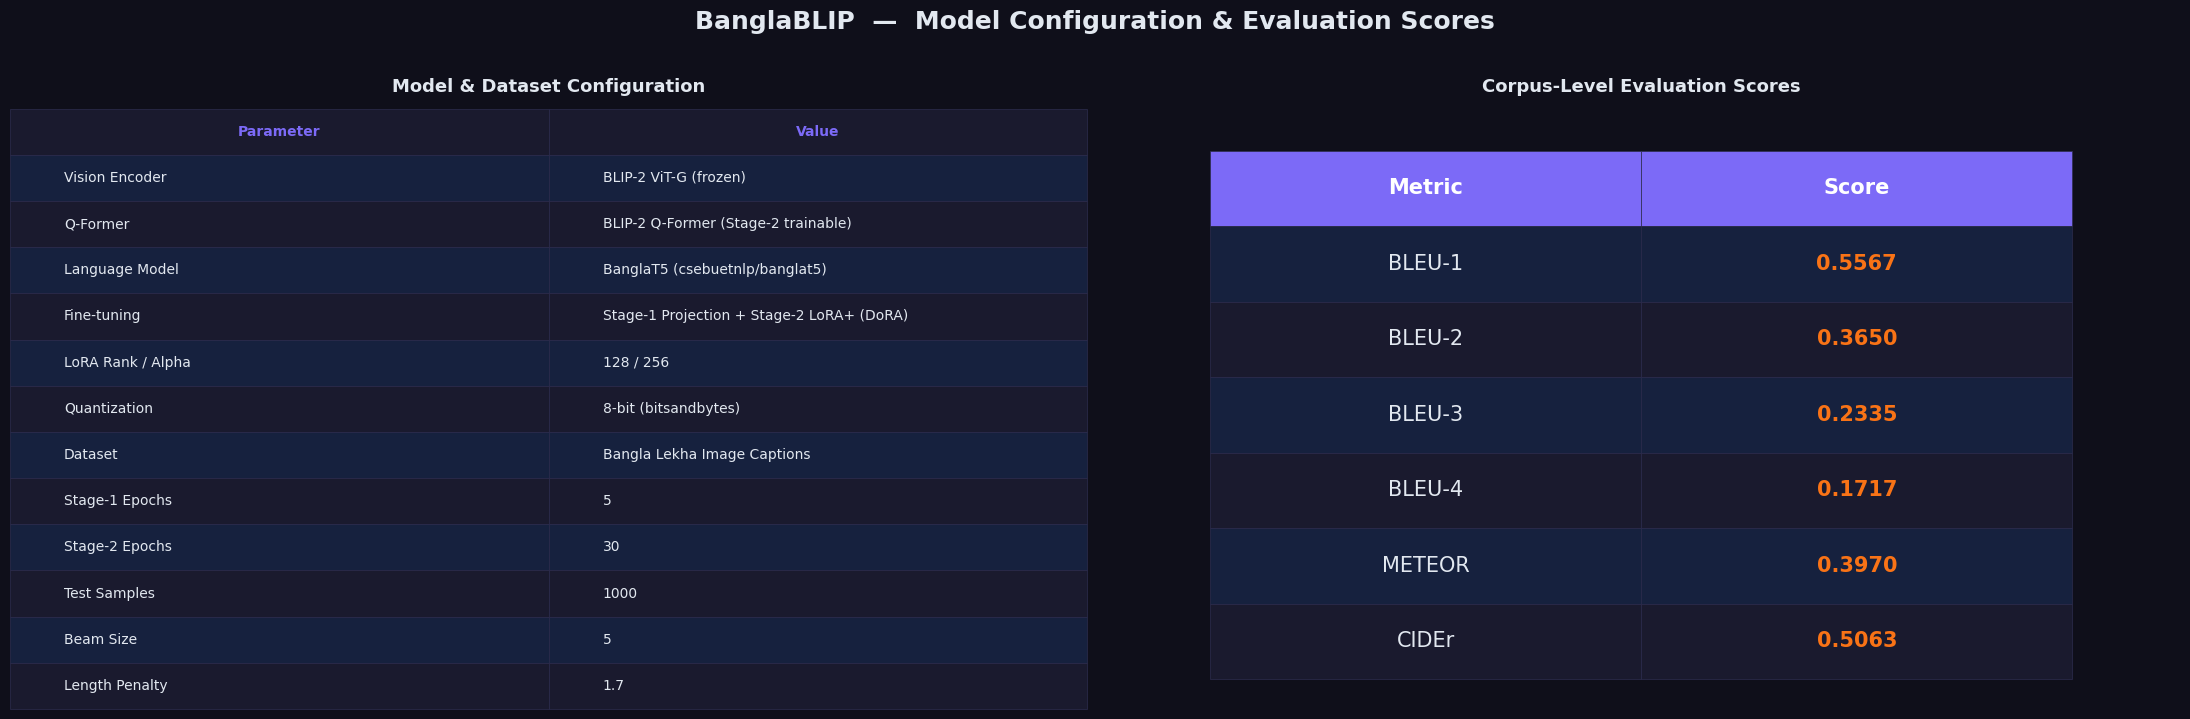

Plot 1 saved → plot1_tables.png


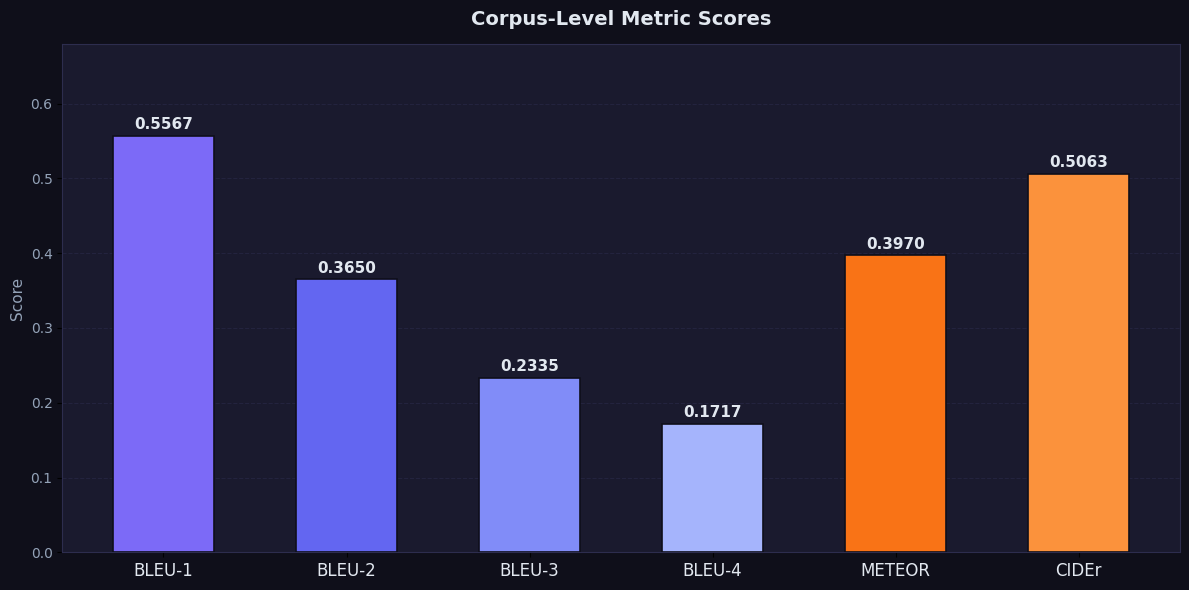

Plot 2 saved → plot2_barchart.png


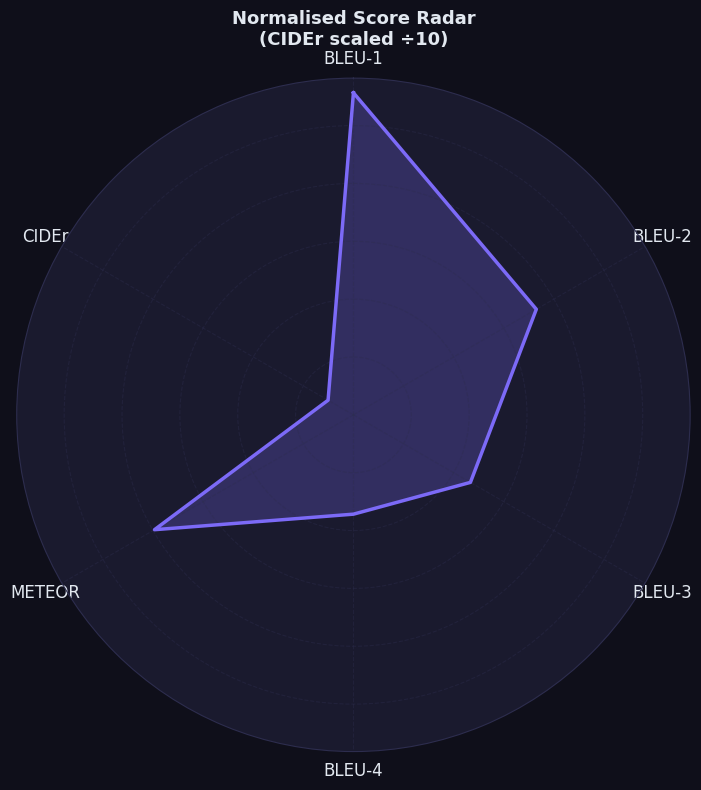

Plot 3 saved → plot3_radar.png


/tmp/ipykernel_44/2490425429.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot([df[c].dropna().values for c in box_cols],


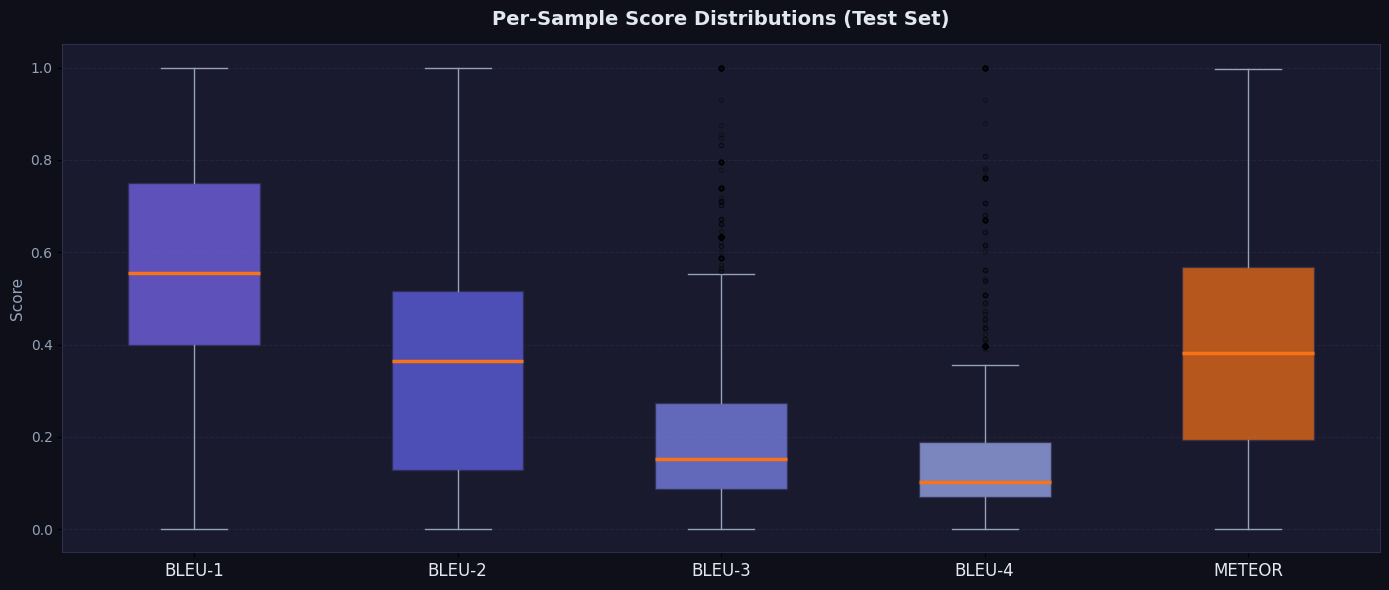

Plot 4 saved → plot4_boxplots.png

═════════════════════════════════════════════
   FINAL EVALUATION SUMMARY
═════════════════════════════════════════════


Metric,Score
BLEU-1,0.5567
BLEU-2,0.3650
BLEU-3,0.2335
BLEU-4,0.1717
METEOR,0.3970
CIDEr,0.5063


In [9]:
# ═══════════════════════════════════════════════════════════════
#  EVALUATION RESULTS — TABLE + GRAPHS (Presentation Ready)
# ═══════════════════════════════════════════════════════════════
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from IPython.display import display

# ── Load CSV ──────────────────────────────────────────────────
csv_path = f"/kaggle/working/blip2_bangla_output/test_eval_results.csv"
df = pd.read_csv(csv_path)

# ── Corpus scores ─────────────────────────────────────────────
corpus_scores = {
    "BLEU-1": df["sentence_bleu1"].mean(),
    "BLEU-2": df["sentence_bleu2"].mean(),
    "BLEU-3": df["sentence_bleu3"].mean(),
    "BLEU-4": df["sentence_bleu4"].mean(),
    "METEOR": df["sentence_meteor"].mean(),
}
from pycocoevalcap.cider.cider import Cider as CiderScorer
gts = {i: row["reference_captions"].split(" ||| ") for i, row in df.iterrows()}
res = {i: [row["generated_caption"]]               for i, row in df.iterrows()}
cider_score, _ = CiderScorer().compute_score(gts, res)
corpus_scores["CIDEr"] = cider_score

# ── Model info ────────────────────────────────────────────────
model_info = {
    "Vision Encoder":      "BLIP-2 ViT-G (frozen)",
    "Q-Former":            "BLIP-2 Q-Former (Stage-2 trainable)",
    "Language Model":      "BanglaT5 (csebuetnlp/banglat5)",
    "Fine-tuning":         "Stage-1 Projection + Stage-2 LoRA+ (DoRA)",
    "LoRA Rank / Alpha":   f"{config.lora_r} / {config.lora_alpha}",
    "Quantization":        "8-bit (bitsandbytes)",
    "Dataset":             "Bangla Lekha Image Captions",
    "Stage-1 Epochs":      str(config.epochs_stage1),
    "Stage-2 Epochs":      str(config.epochs_stage2),
    "Test Samples":        str(len(df)),
    "Beam Size":           str(config.num_beams),
    "Length Penalty":      str(config.length_penalty),
}

# ── Theme ─────────────────────────────────────────────────────
BG      = "#0f0f1a"
CARD    = "#1a1a2e"
CARD2   = "#16213e"
TEXT    = "#e2e8f0"
SUBTEXT = "#94a3b8"
ACCENT  = "#7c6af7"
ACCENT2 = "#f97316"
GRID_C  = "#2d2d4e"
BARS    = ["#7c6af7", "#6366f1", "#818cf8", "#a5b4fc", "#f97316", "#fb923c"]

metrics = list(corpus_scores.keys())
scores  = list(corpus_scores.values())

os.makedirs(config.output_dir, exist_ok=True)

# ══════════════════════════════════════════════════════════════
#  PLOT 1 — Config table + Scores table (side by side)
# ══════════════════════════════════════════════════════════════
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7), facecolor=BG)
fig1.suptitle("BanglaBLIP  —  Model Configuration & Evaluation Scores",
              fontsize=18, fontweight="bold", color=TEXT, y=1.02)

# Config table
ax1.set_facecolor(CARD); ax1.axis("off")
ax1.set_title("Model & Dataset Configuration", color=TEXT,
              fontsize=13, fontweight="bold", pad=12)
tbl1 = ax1.table(cellText=[[k, v] for k, v in model_info.items()],
                 colLabels=["Parameter", "Value"],
                 cellLoc="left", loc="center", bbox=[0, 0, 1, 1])
tbl1.auto_set_font_size(False); tbl1.set_fontsize(10)
for (r, c), cell in tbl1.get_celld().items():
    cell.set_facecolor(CARD if r % 2 == 0 else CARD2)
    cell.set_edgecolor(GRID_C); cell.set_linewidth(0.5)
    cell.set_text_props(color=ACCENT if r == 0 else TEXT,
                        fontweight="bold" if r == 0 else "normal")

# Scores table
ax2.set_facecolor(CARD); ax2.axis("off")
ax2.set_title("Corpus-Level Evaluation Scores", color=TEXT,
              fontsize=13, fontweight="bold", pad=12)
tbl2 = ax2.table(cellText=[[m, f"{s:.4f}"] for m, s in corpus_scores.items()],
                 colLabels=["Metric", "Score"],
                 cellLoc="center", loc="center", bbox=[0.1, 0.05, 0.8, 0.88])
tbl2.auto_set_font_size(False); tbl2.set_fontsize(15)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor(ACCENT)
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(CARD if r % 2 == 0 else CARD2)
        cell.set_text_props(color=ACCENT2 if c == 1 else TEXT,
                            fontweight="bold" if c == 1 else "normal")
    cell.set_edgecolor(GRID_C); cell.set_linewidth(0.5)

plt.tight_layout()
fig1.savefig(f"{config.output_dir}/plot1_tables.png",
             dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Plot 1 saved → plot1_tables.png")

# ══════════════════════════════════════════════════════════════
#  PLOT 2 — Bar chart
# ══════════════════════════════════════════════════════════════
fig2, ax3 = plt.subplots(figsize=(12, 6), facecolor=BG)
ax3.set_facecolor(CARD)
for spine in ax3.spines.values(): spine.set_color(GRID_C)

bars = ax3.bar(metrics, scores, color=BARS, width=0.55,
               edgecolor=BG, linewidth=1.2, zorder=3)
for bar, score in zip(bars, scores):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{score:.4f}", ha="center", va="bottom",
             color=TEXT, fontsize=11, fontweight="bold")

ax3.set_ylim(0, max(scores) * 1.22)
ax3.set_title("Corpus-Level Metric Scores", color=TEXT,
              fontsize=14, fontweight="bold", pad=14)
ax3.set_ylabel("Score", color=SUBTEXT, fontsize=11)
ax3.set_xticklabels(metrics, color=TEXT, fontsize=12)
ax3.yaxis.set_tick_params(labelcolor=SUBTEXT)
ax3.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.5, zorder=0)
fig2.patch.set_facecolor(BG)

plt.tight_layout()
fig2.savefig(f"{config.output_dir}/plot2_barchart.png",
             dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Plot 2 saved → plot2_barchart.png")

# ══════════════════════════════════════════════════════════════
#  PLOT 3 — Radar chart
# ══════════════════════════════════════════════════════════════
fig3, ax4 = plt.subplots(figsize=(8, 8), facecolor=BG,
                          subplot_kw=dict(polar=True))
ax4.set_facecolor(CARD)
ax4.set_theta_offset(np.pi / 2)
ax4.set_theta_direction(-1)

norm   = np.clip(np.array(scores) / np.array([1, 1, 1, 1, 1, 10]), 0, 1)
N      = len(metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
vals   = norm.tolist() + [norm[0]]

ax4.plot(angles, vals, color=ACCENT, linewidth=2.5)
ax4.fill(angles, vals, color=ACCENT, alpha=0.25)
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(metrics, color=TEXT, fontsize=12)
ax4.set_yticklabels([])
ax4.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.4)
ax4.xaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.4)
ax4.spines["polar"].set_color(GRID_C)
ax4.set_title("Normalised Score Radar\n(CIDEr scaled ÷10)",
              color=TEXT, fontsize=13, fontweight="bold", pad=24)
fig3.patch.set_facecolor(BG)

plt.tight_layout()
fig3.savefig(f"{config.output_dir}/plot3_radar.png",
             dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Plot 3 saved → plot3_radar.png")

# ══════════════════════════════════════════════════════════════
#  PLOT 4 — Box plots (per-sample distributions)
# ══════════════════════════════════════════════════════════════
fig4, ax5 = plt.subplots(figsize=(14, 6), facecolor=BG)
ax5.set_facecolor(CARD)
for spine in ax5.spines.values(): spine.set_color(GRID_C)

box_cols   = ["sentence_bleu1", "sentence_bleu2", "sentence_bleu3",
              "sentence_bleu4", "sentence_meteor"]
box_labels = ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "METEOR"]

bp = ax5.boxplot([df[c].dropna().values for c in box_cols],
                 labels=box_labels, patch_artist=True,
                 medianprops=dict(color=ACCENT2, linewidth=2.5),
                 whiskerprops=dict(color=SUBTEXT),
                 capprops=dict(color=SUBTEXT),
                 flierprops=dict(marker="o", color=SUBTEXT, alpha=0.3, markersize=3),
                 zorder=3)
for patch, color in zip(bp["boxes"], BARS):
    patch.set_facecolor(color); patch.set_alpha(0.7); patch.set_edgecolor(GRID_C)

ax5.set_title("Per-Sample Score Distributions (Test Set)",
              color=TEXT, fontsize=14, fontweight="bold", pad=14)
ax5.set_ylabel("Score", color=SUBTEXT, fontsize=11)
ax5.set_xticklabels(box_labels, color=TEXT, fontsize=12)
ax5.yaxis.set_tick_params(labelcolor=SUBTEXT)
ax5.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.5, zorder=0)
fig4.patch.set_facecolor(BG)

plt.tight_layout()
fig4.savefig(f"{config.output_dir}/plot4_boxplots.png",
             dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Plot 4 saved → plot4_boxplots.png")

# ── Inline summary table ──────────────────────────────────────
print("\n" + "═" * 45)
print("   FINAL EVALUATION SUMMARY")
print("═" * 45)
summary_df = pd.DataFrame({
    "Metric": list(corpus_scores.keys()),
    "Score":  [f"{v:.4f}" for v in corpus_scores.values()]
})
display(summary_df.style
    .set_caption("BanglaBLIP — Final Test Set Results")
    .set_properties(**{"text-align": "center"})
    .hide(axis="index"))


# # ═══════════════════════════════════════════════════════════════
# #  EVALUATION RESULTS — TABLE + GRAPHS (Presentation Ready)
# # ═══════════════════════════════════════════════════════════════
# import os
# import pandas as pd
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import matplotlib.gridspec as gridspec
# import numpy as np
# from IPython.display import display

# # ── 1. Load per-sample CSV written by evaluate_captions() ────────────────────
# csv_path = f"{config.output_dir}/test_eval_results.csv"
# df = pd.read_csv(csv_path)

# # ── 2. Compute corpus-level scores (already printed, re-derive for table) ────
# corpus_scores = {
#     "BLEU-1": df["sentence_bleu1"].mean(),
#     "BLEU-2": df["sentence_bleu2"].mean(),
#     "BLEU-3": df["sentence_bleu3"].mean(),
#     "BLEU-4": df["sentence_bleu4"].mean(),
#     "METEOR": df["sentence_meteor"].mean(),
# }

# # CIDEr is corpus-level only — recompute from CSV
# from pycocoevalcap.cider.cider import Cider as CiderScorer
# gts = {i: row["reference_captions"].split(" ||| ") for i, row in df.iterrows()}
# res = {i: [row["generated_caption"]]               for i, row in df.iterrows()}
# cider_score, _ = CiderScorer().compute_score(gts, res)
# corpus_scores["CIDEr"] = cider_score

# # ── 3. MODEL & DATASET INFO ───────────────────────────────────────────────────
# model_info = {
#     "Vision Encoder":  "BLIP-2 ViT-G (frozen)",
#     "Q-Former":        "BLIP-2 Q-Former (Stage-2 trainable)",
#     "Language Model":  "BanglaT5 (csebuetnlp/banglat5)",
#     "Fine-tuning":     "Stage-1 Projection Warmup + Stage-2 LoRA+ (DoRA)",
#     "LoRA Rank":       str(config.lora_r),
#     "LoRA Alpha":      str(config.lora_alpha),
#     "Quantization":    "8-bit (bitsandbytes)",
#     "Dataset":         "BNature Bengali Image Captioning",
#     "Test Samples":    str(len(df)),
#     "Beam Size":       str(config.num_beams),
# }

# # ══════════════════════════════════════════════════════════════════════════════
# #  FIGURE  (3 panels: info table | scores table | bar chart + radar + boxplot)
# # ══════════════════════════════════════════════════════════════════════════════
# fig = plt.figure(figsize=(22, 18), facecolor="#0f0f1a")

# gs = gridspec.GridSpec(
#     3, 2,
#     figure=fig,
#     hspace=0.45,
#     wspace=0.35,
#     left=0.05, right=0.97,
#     top=0.92,  bottom=0.05
# )

# ACCENT     = "#7c6af7"
# ACCENT2    = "#f97316"
# BG         = "#0f0f1a"
# CARD       = "#1a1a2e"
# TEXT       = "#e2e8f0"
# SUBTEXT    = "#94a3b8"
# GRID_C     = "#2d2d4e"
# BAR_COLORS = ["#7c6af7","#6366f1","#818cf8","#a5b4fc","#f97316","#fb923c"]

# # ── Title ─────────────────────────────────────────────────────────────────────
# fig.text(0.5, 0.96, "BanglaBLIP  —  Evaluation Results",
#          ha="center", va="center", fontsize=22, fontweight="bold", color=TEXT)
# fig.text(0.5, 0.935, "Bengali Image Captioning  |  BNature Dataset  |  BLEU / METEOR / CIDEr",
#          ha="center", va="center", fontsize=12, color=SUBTEXT)

# # ── Panel 1: Model & Dataset info table ───────────────────────────────────────
# ax1 = fig.add_subplot(gs[0, 0])
# ax1.set_facecolor(CARD)
# ax1.axis("off")
# ax1.set_title("Model & Dataset Configuration", color=TEXT,
#               fontsize=13, fontweight="bold", pad=12)

# info_rows = [[k, v] for k, v in model_info.items()]
# tbl1 = ax1.table(cellText=info_rows, colLabels=["Parameter", "Value"],
#                  cellLoc="left", loc="center", bbox=[0, 0, 1, 1])
# tbl1.auto_set_font_size(False)
# tbl1.set_fontsize(10)
# for (r, c), cell in tbl1.get_celld().items():
#     cell.set_facecolor(CARD if r % 2 == 0 else "#16213e")
#     cell.set_edgecolor(GRID_C)
#     cell.set_text_props(color=TEXT if r > 0 else ACCENT,
#                         fontweight="bold" if r == 0 else "normal")
#     cell.set_linewidth(0.5)

# # ── Panel 2: Corpus scores table ──────────────────────────────────────────────
# ax2 = fig.add_subplot(gs[0, 1])
# ax2.set_facecolor(CARD)
# ax2.axis("off")
# ax2.set_title("Corpus-Level Evaluation Scores", color=TEXT,
#               fontsize=13, fontweight="bold", pad=12)

# score_rows = [[metric, f"{score:.4f}"] for metric, score in corpus_scores.items()]
# tbl2 = ax2.table(cellText=score_rows, colLabels=["Metric", "Score"],
#                  cellLoc="center", loc="center", bbox=[0.1, 0.05, 0.8, 0.9])
# tbl2.auto_set_font_size(False)
# tbl2.set_fontsize(13)
# for (r, c), cell in tbl2.get_celld().items():
#     if r == 0:
#         cell.set_facecolor(ACCENT)
#         cell.set_text_props(color="white", fontweight="bold")
#     else:
#         cell.set_facecolor(CARD if r % 2 == 0 else "#16213e")
#         cell.set_text_props(color=TEXT if c == 0 else ACCENT2,
#                             fontweight="normal" if c == 0 else "bold")
#     cell.set_edgecolor(GRID_C)
#     cell.set_linewidth(0.5)

# # ── Panel 3: Bar chart ────────────────────────────────────────────────────────
# ax3 = fig.add_subplot(gs[1, 0])
# ax3.set_facecolor(CARD)
# ax3.spines[["top","right","left","bottom"]].set_color(GRID_C)
# ax3.tick_params(colors=TEXT)

# metrics = list(corpus_scores.keys())
# scores  = list(corpus_scores.values())
# bars = ax3.bar(metrics, scores, color=BAR_COLORS, width=0.55,
#                edgecolor=BG, linewidth=1.2, zorder=3)
# for bar, score in zip(bars, scores):
#     ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
#              f"{score:.4f}", ha="center", va="bottom",
#              color=TEXT, fontsize=10, fontweight="bold")

# ax3.set_ylim(0, max(scores) * 1.2)
# ax3.set_title("Corpus-Level Metric Scores", color=TEXT,
#               fontsize=12, fontweight="bold", pad=10)
# ax3.set_ylabel("Score", color=SUBTEXT, fontsize=10)
# ax3.set_xticklabels(metrics, color=TEXT, fontsize=11)
# ax3.yaxis.set_tick_params(labelcolor=SUBTEXT)
# ax3.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.5, zorder=0)

# # ── Panel 4: Radar chart ──────────────────────────────────────────────────────
# ax4 = fig.add_subplot(gs[1, 1], polar=True)
# ax4.set_facecolor(CARD)
# ax4.set_theta_offset(np.pi / 2)
# ax4.set_theta_direction(-1)

# radar_raw  = np.array(list(corpus_scores.values()))
# radar_norm = np.clip(radar_raw / np.array([1, 1, 1, 1, 1, 10]), 0, 1)  # CIDEr scaled /10
# N      = len(metrics)
# angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
# angles += angles[:1]
# vals   = radar_norm.tolist() + radar_norm[:1].tolist()

# ax4.plot(angles, vals, color=ACCENT, linewidth=2)
# ax4.fill(angles, vals, color=ACCENT, alpha=0.25)
# ax4.set_xticks(angles[:-1])
# ax4.set_xticklabels(metrics, color=TEXT, fontsize=11)
# ax4.set_yticklabels([])
# ax4.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.4)
# ax4.xaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.4)
# ax4.spines["polar"].set_color(GRID_C)
# ax4.set_title("Normalised Score Radar\n(CIDEr scaled ÷10)", color=TEXT,
#               fontsize=12, fontweight="bold", pad=20)

# # ── Panel 5: Box plots ────────────────────────────────────────────────────────
# ax5 = fig.add_subplot(gs[2, :])
# ax5.set_facecolor(CARD)
# ax5.spines[["top","right","left","bottom"]].set_color(GRID_C)

# box_cols   = ["sentence_bleu1","sentence_bleu2","sentence_bleu3","sentence_bleu4","sentence_meteor"]
# box_labels = ["BLEU-1","BLEU-2","BLEU-3","BLEU-4","METEOR"]
# box_data   = [df[c].dropna().values for c in box_cols]

# bp = ax5.boxplot(box_data, labels=box_labels, patch_artist=True,
#                  medianprops=dict(color=ACCENT2, linewidth=2),
#                  whiskerprops=dict(color=SUBTEXT),
#                  capprops=dict(color=SUBTEXT),
#                  flierprops=dict(marker="o", color=SUBTEXT, alpha=0.3, markersize=3),
#                  zorder=3)
# for patch, color in zip(bp["boxes"], BAR_COLORS):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)
#     patch.set_edgecolor(GRID_C)

# ax5.set_title("Per-Sample Score Distributions (Test Set)", color=TEXT,
#               fontsize=12, fontweight="bold", pad=10)
# ax5.set_ylabel("Score", color=SUBTEXT, fontsize=10)
# ax5.set_xticklabels(box_labels, color=TEXT, fontsize=11)
# ax5.yaxis.set_tick_params(labelcolor=SUBTEXT)
# ax5.yaxis.grid(True, color=GRID_C, linestyle="--", alpha=0.5, zorder=0)

# # ── Save & show ───────────────────────────────────────────────────────────────
# out_img = f"{config.output_dir}/evaluation_results.png"
# os.makedirs(config.output_dir, exist_ok=True)
# plt.savefig(out_img, dpi=150, bbox_inches="tight", facecolor=BG)
# plt.show()
# print(f"\nSaved presentation graphic → {out_img}")

# # ── Clean summary table ───────────────────────────────────────────────────────
# print("\n" + "═"*45)
# print("   FINAL EVALUATION SUMMARY")
# print("═"*45)
# summary_df = pd.DataFrame({
#     "Metric": list(corpus_scores.keys()),
#     "Score":  [f"{v:.4f}" for v in corpus_scores.values()]
# })
# display(summary_df.style
#     .set_caption("BanglaBLIP — Test Set Results")
#     .set_properties(**{"text-align": "center"})
#     .hide(axis="index"))